In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Feature extraction & topic modeling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Word cloud
from wordcloud import WordCloud

# Make sure NLTK resources are available
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [2]:
!pip install wordcloud


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import sys
print(sys.version)
print(sys.executable)

3.11.13 (main, Jun  5 2025, 08:21:08) [Clang 14.0.6 ]
/opt/anaconda3/envs/py31113/bin/python


In [4]:
import sys
!{sys.executable} -m pip install wordcloud nltk

In [5]:
import sys
!{sys.executable} -m pip install wordcloud nltk pandas numpy matplotlib seaborn scikit-learn scipy

In [6]:
# Load the cleaned 311 dataset
data = pd.read_csv("311_2025_manhattan_cleaned.csv")

print("Shape:", data.shape)
print("Number of records:", len(data))
print("Number of columns:", data.shape[1])

data.head()

Shape: (18743, 19)
Number of records: 18743
Number of columns: 19


,unique_key,created_date,closed_date,year,month,season,day_of_week,hour,is_weekend,complaint_type,descriptor,agency,location_type,incident_zip,incident_address,community_board,resolution_description,response_hours,response_hours_flag
0,63800912,2025-01-17 17:45:55,2025-02-24 16:49:54,2025,1,Winter,4,17,0,General,Bell/Buzzer/Intercom,HPD,Residential Building,10028,509 EAST 81 STREET,08 MANHATTAN,HPD attempted to conduct an inspection in resp...,911.066389,0
1,63794210,2025-01-17 17:46:39,2025-01-23 00:00:00,2025,1,Winter,4,17,0,Investigations And Discipline (Iad),Investigative Inspection,DOB,NaN,10021,150 EAST 69 STREET,08 MANHATTAN,The Department of Buildings investigated this ...,126.222500,0
2,63795390,2025-01-17 17:47:00,2025-01-18 01:05:00,2025,1,Winter,4,17,0,Water System,Dirty Water (We),DEP,NaN,10036,520 WEST 43 STREET,04 MANHATTAN,The Department of Environmental Protection inv...,7.300000,0
3,63793374,2025-01-17 17:48:56,2025-01-21 10:08:46,2025,1,Winter,4,17,0,Heat/Hot Water,Entire Building,HPD,Residential Building,10031,541 WEST 142 STREET,09 MANHATTAN,This complaint is a duplicate of a building-wi...,88.330556,0
4,63798442,2025-01-17 17:48:56,2025-01-21 10:08:46,2025,1,Winter,4,17,0,Heat/Hot Water,Entire Building,HPD,Residential Building,10031,541 WEST 142 STREET,09 MANHATTAN,This complaint is a duplicate of a building-wi...,88.330556,0


In [7]:
# Check missing values across all columns
missing = data.isna().sum()
missing_pct = (data.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print("Columns with missing values:")
missing_summary

Columns with missing values:


,missing_count,missing_pct
location_type,2443,13.03
descriptor,1073,5.72
incident_address,517,2.76
resolution_description,511,2.73


Records per month:
month
1     1464
2     1608
3     1626
4     1525
5     1630
6     1551
7     1566
8     1582
9     1615
10    1475
11    1572
12    1529
Name: count, dtype: int64

Total: 18743
Average per month: 1562


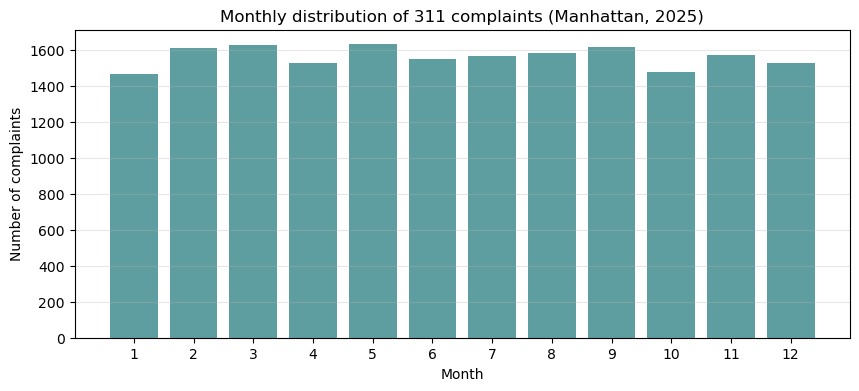

In [8]:
# Records by month
monthly_counts = data['month'].value_counts().sort_index()
print("Records per month:")
print(monthly_counts)
print(f"\nTotal: {monthly_counts.sum()}")
print(f"Average per month: {monthly_counts.mean():.0f}")

# Plot
plt.figure(figsize=(10, 4))
plt.bar(monthly_counts.index, monthly_counts.values, color='cadetblue')
plt.xlabel('Month')
plt.ylabel('Number of complaints')
plt.title('Monthly distribution of 311 complaints (Manhattan, 2025)')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)
plt.show()

Total unique complaint types: 131

Top 15 complaint types:
complaint_type
Heat/Hot Water                1995
Noise - Residential           1844
Illegal Parking               1762
Noise - Street/Sidewalk       1501
Encampment                     824
Noise - Commercial             708
Noise                          593
Unsanitary Condition           555
Vendor Enforcement             438
Homeless Person Assistance     422
Plumbing                       413
Dirty Condition                371
Water System                   360
Street Condition               318
Paint/Plaster                  311
Name: count, dtype: int64


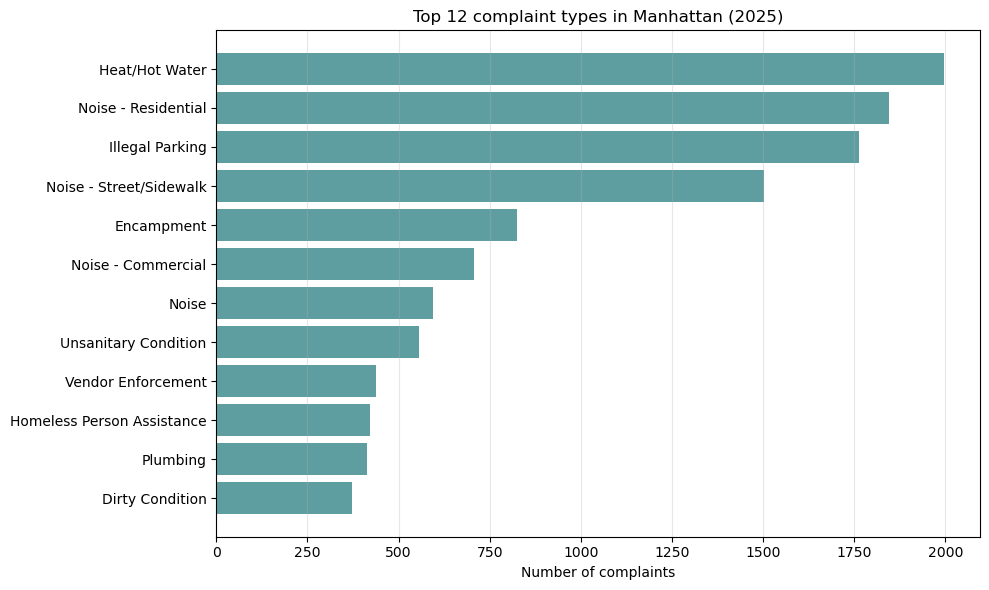


Top 4 complaint types account for 37.9% of all complaints
Top 10 complaint types account for 56.8% of all complaints


In [9]:
# Top 15 complaint types
complaint_counts = data['complaint_type'].value_counts()

print("Total unique complaint types:", complaint_counts.shape[0])
print("\nTop 15 complaint types:")
print(complaint_counts.head(15))

# Plot top 12 (cleaner for slides)
top12 = complaint_counts.head(12).iloc[::-1]  # reverse so largest is on top in horizontal bar

plt.figure(figsize=(10, 6))
plt.barh(top12.index, top12.values, color='cadetblue')
plt.xlabel('Number of complaints')
plt.title('Top 12 complaint types in Manhattan (2025)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# How concentrated are complaints?
top4_share = complaint_counts.head(4).sum() / len(data) * 100
top10_share = complaint_counts.head(10).sum() / len(data) * 100
print(f"\nTop 4 complaint types account for {top4_share:.1f}% of all complaints")
print(f"Top 10 complaint types account for {top10_share:.1f}% of all complaints")

Total unique agencies: 15

Top 10 agencies:
agency
NYPD     7482
HPD      4378
DSNY     1640
DEP      1303
DOT       979
DHS       712
DOHMH     647
DOB       610
TLC       412
DPR       392
Name: count, dtype: int64


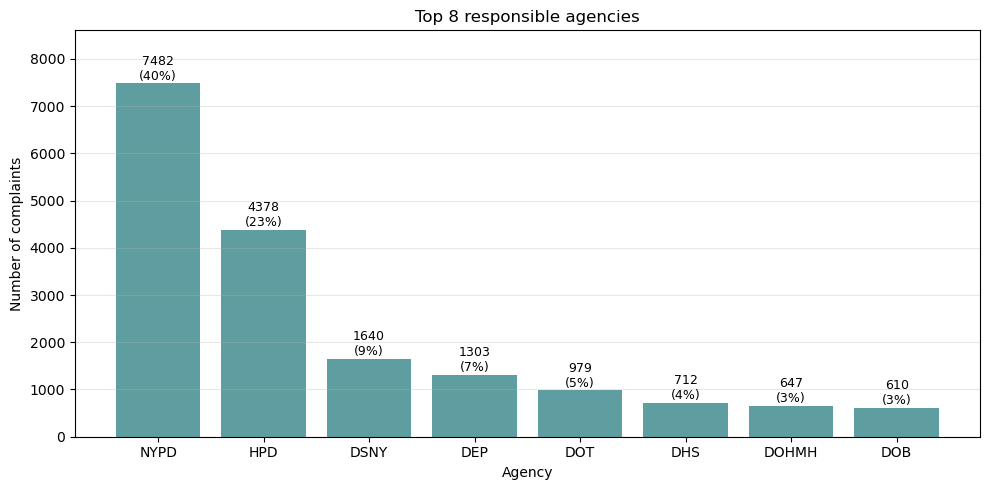


NYPD + HPD handle 63.3% of all complaints


In [10]:
# Which agencies handle the complaints?
agency_counts = data['agency'].value_counts()

print("Total unique agencies:", agency_counts.shape[0])
print("\nTop 10 agencies:")
print(agency_counts.head(10))

# Plot top 8
top8 = agency_counts.head(8)

plt.figure(figsize=(10, 5))
plt.bar(top8.index, top8.values, color='cadetblue')
plt.xlabel('Agency')
plt.ylabel('Number of complaints')
plt.title('Top 8 responsible agencies')
plt.grid(axis='y', alpha=0.3)

# Annotate count + pct on each bar
for i, (agency, count) in enumerate(top8.items()):
    pct = count / len(data) * 100
    plt.text(i, count + 80, f'{count}\n({pct:.0f}%)', ha='center', fontsize=9)

plt.ylim(0, top8.max() * 1.15)
plt.tight_layout()
plt.show()

# Concentration
top2_share = agency_counts.head(2).sum() / len(data) * 100
print(f"\nNYPD + HPD handle {top2_share:.1f}% of all complaints")

In [11]:
# Focus on descriptor field for text analysis
# Drop rows where descriptor is missing
desc_data = data.dropna(subset=['descriptor']).copy()
print(f"Records with valid descriptor: {len(desc_data)} (dropped {len(data) - len(desc_data)})")

# Clean descriptor text
# Steps: lowercase, remove punctuation, remove digits, collapse whitespace
cleaned_desc = []
for text in desc_data['descriptor']:
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)              # remove digits
    text = re.sub(r'[^\w\s]', ' ', text)         # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()     # collapse whitespace
    cleaned_desc.append(text)

desc_data['descriptor_clean'] = cleaned_desc

# Compare original vs cleaned for first 5 rows
print("\nBefore vs after cleaning (first 5 rows):")
for i in range(5):
    print(f"Original: {desc_data['descriptor'].iloc[i]}")
    print(f"Cleaned:  {desc_data['descriptor_clean'].iloc[i]}")
    print('-' * 60)

Records with valid descriptor: 17670 (dropped 1073)

Before vs after cleaning (first 5 rows):
Original: Bell/Buzzer/Intercom
Cleaned:  bell buzzer intercom
------------------------------------------------------------
Original: Investigative Inspection
Cleaned:  investigative inspection
------------------------------------------------------------
Original: Dirty Water (We)
Cleaned:  dirty water we
------------------------------------------------------------
Original: Entire Building
Cleaned:  entire building
------------------------------------------------------------
Original: Entire Building
Cleaned:  entire building
------------------------------------------------------------


In [12]:
# WORKING: Compare two cleaning approaches before settling on regex
# We considered both string-method and regex-based cleaning

sample_text = "   Loud Music/Party!!  At 2am  (Apt 5B)   "
print(f"Original messy text: '{sample_text}'\n")

# Approach 1: String-method based (using str.translate and split)
import string
str_cleaned = sample_text.lower()
str_cleaned = ' '.join(str_cleaned.split())
str_cleaned = str_cleaned.translate(str.maketrans('', '', string.punctuation))
print(f"String-method cleaned: '{str_cleaned}'")

# Approach 2: Regex based (our final choice)
regex_cleaned = sample_text.lower()
regex_cleaned = re.sub(r'\d+', '', regex_cleaned)
regex_cleaned = re.sub(r'[^\w\s]', ' ', regex_cleaned)
regex_cleaned = re.sub(r'\s+', ' ', regex_cleaned).strip()
print(f"Regex-based cleaned:   '{regex_cleaned}'")

print("\n--> We chose the regex approach because:")
print("    1. It removes digits as a separate step (string method doesn't)")
print("    2. It collapses multiple whitespaces more cleanly")
print("    3. It is the same approach demonstrated in our text analysis class notes")

Original messy text: '   Loud Music/Party!!  At 2am  (Apt 5B)   '

String-method cleaned: 'loud musicparty at 2am apt 5b'
Regex-based cleaned:   'loud music party at am apt b'

--> We chose the regex approach because:
    1. It removes digits as a separate step (string method doesn't)
    2. It collapses multiple whitespaces more cleanly
    3. It is the same approach demonstrated in our text analysis class notes


Descriptor text statistics:
       char_count  word_count  unique_word_count
count    17670.00    17670.00           17670.00
mean        16.93        2.64               2.63
std          9.04        1.31               1.30
min          2.00        1.00               1.00
25%         12.00        2.00               2.00
50%         16.00        2.00               2.00
75%         18.00        3.00               3.00
max         71.00       11.00              11.00


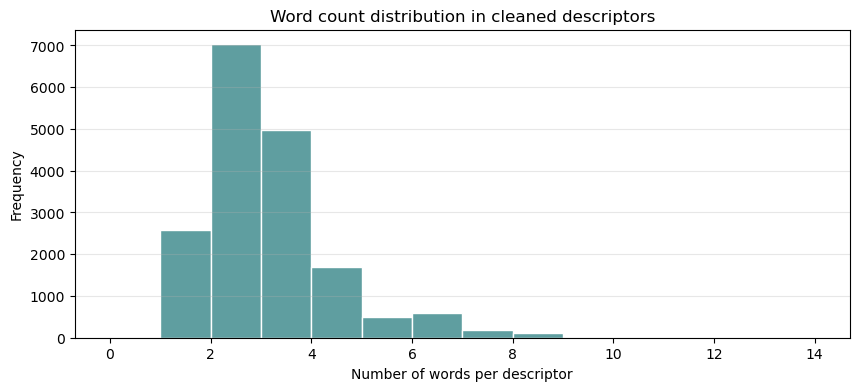

In [13]:
# Basic text statistics on cleaned descriptors
char_counts = []
word_counts = []
unique_word_counts = []

for text in desc_data['descriptor_clean']:
    words = text.split()
    char_counts.append(len(text))
    word_counts.append(len(words))
    unique_word_counts.append(len(set(words)))

desc_data['char_count'] = char_counts
desc_data['word_count'] = word_counts
desc_data['unique_word_count'] = unique_word_counts

# Summary
print("Descriptor text statistics:")
print(desc_data[['char_count', 'word_count', 'unique_word_count']].describe().round(2))

# Distribution of word counts
plt.figure(figsize=(10, 4))
plt.hist(desc_data['word_count'], bins=range(0, 15), color='cadetblue', edgecolor='white')
plt.xlabel('Number of words per descriptor')
plt.ylabel('Frequency')
plt.title('Word count distribution in cleaned descriptors')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [14]:
# TF-IDF on cleaned descriptors
# Use 1-grams and 2-grams to capture phrases like "loud music"
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=100,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(desc_data['descriptor_clean'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("(rows = number of descriptors, columns = number of features)")
print("\nFirst 30 features in vocabulary:")
print(tfidf_vectorizer.get_feature_names_out()[:30])

TF-IDF matrix shape: (17670, 100)
(rows = number of descriptors, columns = number of features)

First 30 features in vocabulary:
['access' 'air' 'apartment' 'banging' 'banging pounding' 'basin' 'bike'
 'bike lane' 'blocked' 'blocked bike' 'blocked hydrant' 'blocked sidewalk'
 'blocking' 'blocking traffic' 'building' 'car' 'car truck' 'ceiling'
 'chronic' 'complaint' 'complaint non' 'condition' 'construction'
 'construction hours' 'defective' 'dog' 'door' 'double' 'double parked'
 'driver']


In [15]:
# WORKING: Compare TF-IDF max_features = 50, 100, 200 to justify our choice
# We want enough features to capture topics but not so many that noise dominates

for max_feat in [50, 100, 200]:
    tfidf_test = TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        max_features=max_feat,
        ngram_range=(1, 2)
    )
    tfidf_test.fit(desc_data['descriptor_clean'])

    feats = tfidf_test.get_feature_names_out()
    print(f"max_features = {max_feat}")
    print(f"  First 10 features:  {feats[:10].tolist()}")
    print(f"  Last 10 features:   {feats[-10:].tolist()}")
    print()

print("--> We chose max_features = 100 because:")
print("    50: misses meaningful tail terms (e.g. 'hydrant', 'banging')")
print("    200: starts including very rare or noisy terms")
print("    100: balances coverage and signal quality")

max_features = 50
  First 10 features:  ['apartment', 'banging', 'banging pounding', 'blocked', 'blocked hydrant', 'building', 'car', 'chronic', 'complaint', 'construction']
  Last 10 features:   ['sidewalk', 'sign', 'sign violation', 'talking', 'trash', 'truck', 'use', 'vendor', 'violation', 'water']

max_features = 100
  First 10 features:  ['access', 'air', 'apartment', 'banging', 'banging pounding', 'basin', 'bike', 'bike lane', 'blocked', 'blocked bike']
  Last 10 features:   ['trash', 'truck', 'truck music', 'use', 'vehicle', 'vendor', 'violation', 'wall', 'water', 'water supply']

max_features = 200
  First 10 features:  ['access', 'ad', 'air', 'air odor', 'alternate', 'alternate service', 'apartment', 'bag', 'bag wallet', 'banging']
  Last 10 features:   ['wa', 'wall', 'wallet', 'waste', 'water', 'water supply', 'wc', 'window', 'window frame', 'work']

--> We chose max_features = 100 because:
    50: misses meaningful tail terms (e.g. 'hydrant', 'banging')
    200: starts inclu

In [16]:
# WORKING: Compare default English stopwords vs custom 311-context stopwords
# Some words like "non", "use", "general" appear often in 311 descriptors
# but carry no thematic meaning. We test if removing them improves topic clarity.

# Define custom stopwords on top of standard English ones
domain_stopwords = ['non', 'use', 'general', 'condition', 'complaint', 'nm']
custom_stop = list(stopwords.words('english')) + domain_stopwords

# Approach A: default English stopwords only (what we use in main analysis)
tfidf_default = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=30,
    ngram_range=(1, 2)
)
tfidf_default.fit(desc_data['descriptor_clean'])

# Approach B: with custom domain stopwords
tfidf_custom = TfidfVectorizer(
    lowercase=True,
    stop_words=custom_stop,
    max_features=30,
    ngram_range=(1, 2)
)
tfidf_custom.fit(desc_data['descriptor_clean'])

print("Top 30 features — DEFAULT English stopwords:")
print(tfidf_default.get_feature_names_out().tolist())
print()
print("Top 30 features — CUSTOM stopwords (added: 'non', 'use', 'general', 'condition', 'complaint', 'nm'):")
print(tfidf_custom.get_feature_names_out().tolist())

print("\n--> We kept the default English stopwords because:")
print("    Custom stopwords removed 'condition' and 'complaint',")
print("    but these words actually carry meaning in 311 context")
print("    (e.g. 'unsanitary condition', 'noise complaint').")
print("    Removing them would damage topic interpretability.")

Top 30 features — DEFAULT English stopwords:
['apartment', 'banging', 'banging pounding', 'blocked', 'building', 'construction', 'entire', 'entire building', 'food', 'food vendor', 'hydrant', 'loud', 'loud music', 'loud talking', 'music', 'music party', 'noise', 'non', 'parking', 'parking sign', 'party', 'posted', 'posted parking', 'pounding', 'sign', 'sign violation', 'talking', 'trash', 'vendor', 'violation']

Top 30 features — CUSTOM stopwords (added: 'non', 'use', 'general', 'condition', 'complaint', 'nm'):
['apartment', 'banging', 'banging pounding', 'blocked', 'building', 'chronic', 'construction', 'entire', 'entire building', 'food', 'food vendor', 'hydrant', 'loud', 'loud music', 'loud talking', 'music', 'music party', 'noise', 'parking', 'parking sign', 'party', 'posted', 'posted parking', 'pounding', 'sign', 'sign violation', 'talking', 'trash', 'vendor', 'violation']

--> We kept the default English stopwords because:
    Custom stopwords removed 'condition' and 'complaint',

Top 20 terms by total TF-IDF score:
            term  tfidf_score
            loud  1424.795177
           music  1235.959477
           party  1221.325869
     music party  1221.325869
      loud music  1221.325869
        building   857.772916
          entire   828.092941
 entire building   815.546342
       apartment   592.000000
           trash   448.838994
         blocked   448.097295
        pounding   439.940905
         banging   439.940905
banging pounding   439.940905
         talking   439.393975
    loud talking   439.393975
         hydrant   331.094084
            food   324.001592
         parking   315.954081
           noise   313.074882


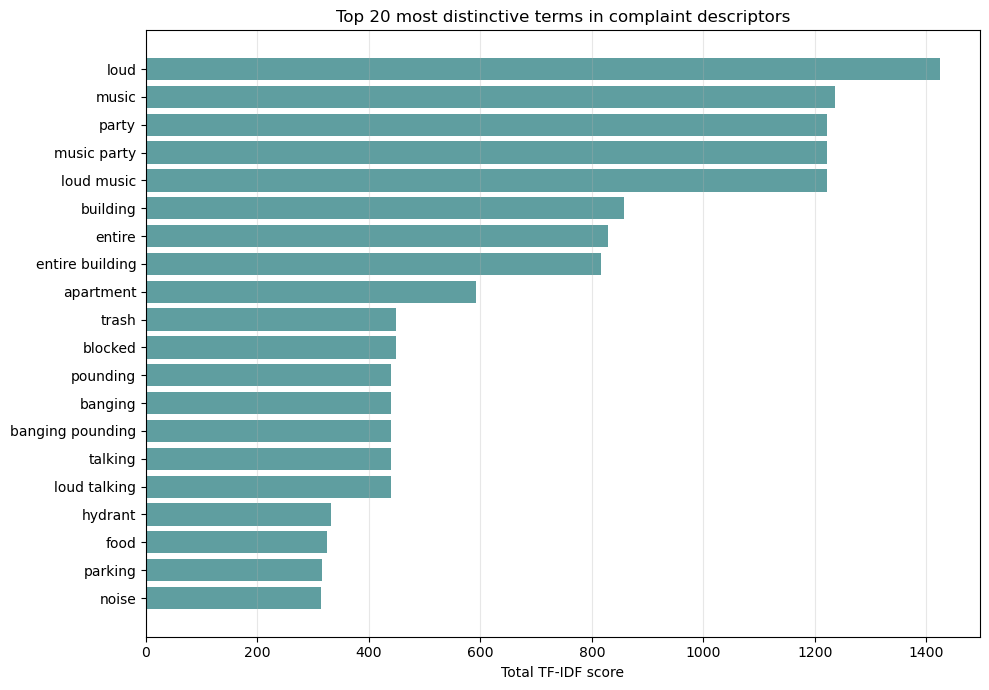

In [17]:
# Sum TF-IDF scores across all descriptors to find globally most distinctive terms
tfidf_array = tfidf_matrix.toarray()
feature_names = tfidf_vectorizer.get_feature_names_out()

term_scores = tfidf_array.sum(axis=0)
term_score_df = pd.DataFrame({
    'term': feature_names,
    'tfidf_score': term_scores
}).sort_values('tfidf_score', ascending=False)

print("Top 20 terms by total TF-IDF score:")
print(term_score_df.head(20).to_string(index=False))

# Plot top 20
top20 = term_score_df.head(20).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top20['term'], top20['tfidf_score'], color='cadetblue')
plt.xlabel('Total TF-IDF score')
plt.title('Top 20 most distinctive terms in complaint descriptors')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Total words after stopword removal: 42166
Unique words: 700

Top 15 most frequent words:
  loud: 3386
  music: 2823
  party: 2678
  building: 1492
  entire: 1418
  blocked: 816
  banging: 762
  pounding: 762
  parking: 747
  talking: 679
  noise: 625
  sign: 622
  apartment: 592
  violation: 583
  posted: 571


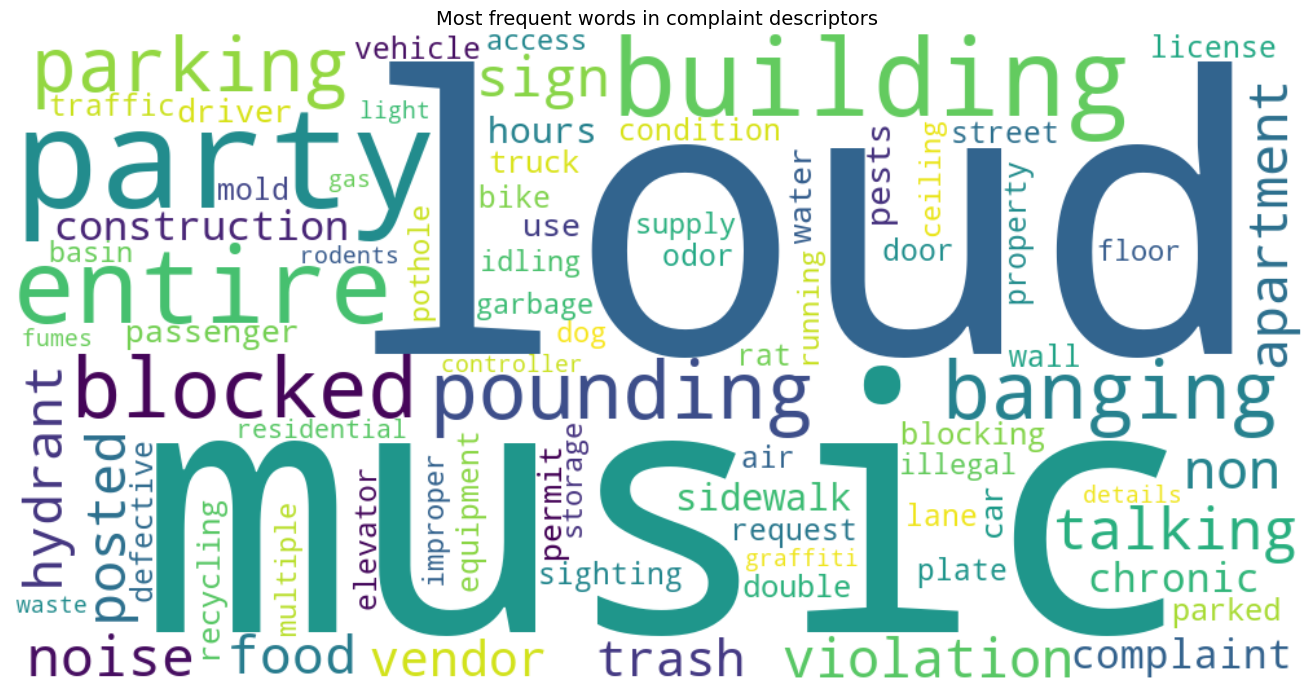

In [18]:
# Word cloud based on word frequencies in cleaned descriptors
# (frequency-based, not TF-IDF, for clearer visual)
all_words = []
for text in desc_data['descriptor_clean']:
    all_words.extend(text.split())

# Remove standard English stopwords
english_stopwords = set(stopwords.words('english'))
all_words = [w for w in all_words if w not in english_stopwords and len(w) > 2]

word_freq = Counter(all_words)
print("Total words after stopword removal:", len(all_words))
print("Unique words:", len(word_freq))
print("\nTop 15 most frequent words:")
for word, count in word_freq.most_common(15):
    print(f"  {word}: {count}")

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=80,
    colormap='viridis'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in complaint descriptors', fontsize=14)
plt.tight_layout()
plt.show()

### Note on word cloud styling

We tested two background colors for the word cloud:

- **Black background with `colormap='viridis'`** — high contrast,
  visually striking, matches the style shown in our class notes.
- **White background with `colormap='viridis'`** (final choice) —
  blends seamlessly into slide decks (which are typically white)
  and avoids large dark blocks dominating the layout.

Since the word cloud is intended for the presentation, we
prioritized visual integration over the original styling.

Count matrix shape: (17670, 100)
n_topics = 3: perplexity = 40.36
n_topics = 4: perplexity = 35.98
n_topics = 5: perplexity = 33.97
n_topics = 6: perplexity = 27.29
n_topics = 7: perplexity = 25.89
n_topics = 8: perplexity = 24.78


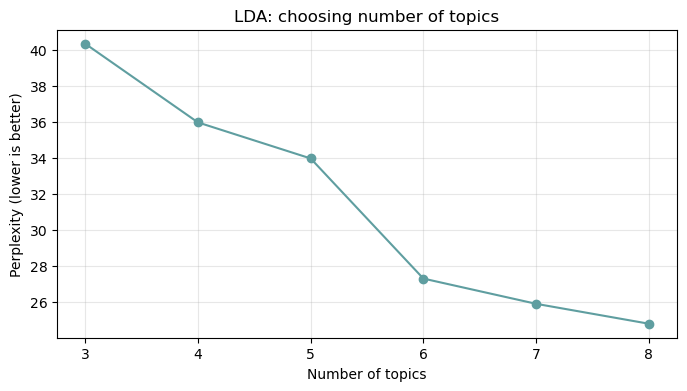

In [19]:
# Build a count-based matrix for LDA (LDA works better with raw counts than TF-IDF)
count_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=100,
    ngram_range=(1, 2)
)

count_matrix = count_vectorizer.fit_transform(desc_data['descriptor_clean'])
print("Count matrix shape:", count_matrix.shape)

# Try different numbers of topics and compare perplexity
# Lower perplexity = better fit
n_topics_range = range(3, 9)
perplexities = []

for n in n_topics_range:
    lda = LatentDirichletAllocation(
        n_components=n,
        random_state=617,
        max_iter=20
    )
    lda.fit(count_matrix)
    perplexities.append(lda.perplexity(count_matrix))
    print(f"n_topics = {n}: perplexity = {lda.perplexity(count_matrix):.2f}")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(list(n_topics_range), perplexities, marker='o', color='cadetblue')
plt.xlabel('Number of topics')
plt.ylabel('Perplexity (lower is better)')
plt.title('LDA: choosing number of topics')
plt.grid(alpha=0.3)
plt.show()

In [20]:
# Fit LDA with the chosen number of topics
# We pick 4 topics — matches our intuition from the EDA (Housing/Noise/Street/Sanitation)
n_topics = 4

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=617,
    max_iter=50
)

lda.fit(count_matrix)
feature_names = count_vectorizer.get_feature_names_out()

print(f"LDA fitted with {n_topics} topics. Top 12 words per topic:\n")
for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-12:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

LDA fitted with 4 topics. Top 12 words per topic:

Topic 1: trash, chronic, non, non chronic, recycling, plate, condition, license, door, mold, license plate, floor
Topic 2: music, loud, party, music party, loud music, apartment, blocked, hydrant, sidewalk, blocked hydrant, use, water
Topic 3: parking, sign, violation, posted, parking sign, sign violation, posted parking, noise, construction, complaint, noise construction, hours
Topic 4: building, entire, entire building, banging, banging pounding, pounding, talking, loud talking, loud, food, vendor, food vendor


In [21]:
# Compare with K=5 to see if topics become cleaner
n_topics_alt = 5

lda_alt = LatentDirichletAllocation(
    n_components=n_topics_alt,
    random_state=617,
    max_iter=50
)

lda_alt.fit(count_matrix)

print(f"LDA fitted with {n_topics_alt} topics. Top 12 words per topic:\n")
for topic_idx, topic in enumerate(lda_alt.components_):
    top_words_idx = topic.argsort()[-12:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

LDA fitted with 5 topics. Top 12 words per topic:

Topic 1: trash, chronic, non, non chronic, plate, condition, license, door, equipment, license plate, floor, illegal
Topic 2: blocked, apartment, noise, hydrant, construction, noise construction, sidewalk, hours, blocked hydrant, construction hours, nm, hours nm
Topic 3: parking, sign, violation, posted, posted parking, sign violation, parking sign, complaint, driver, driver complaint, passenger, non passenger
Topic 4: loud, loud talking, talking, food, vendor, food vendor, pests, recycling, blocking, parked, double, double parked
Topic 5: loud, music, loud music, music party, party, building, entire, entire building, pounding, banging, banging pounding, mold


In [22]:
# WORKING: Try K=3 LDA to complete the K=3/4/5 comparison
# We compared K=4 vs K=5 (above). Now we also test K=3 to confirm
# our final choice of K=4 is well-grounded.

n_topics_low = 3

lda_low = LatentDirichletAllocation(
    n_components=n_topics_low,
    random_state=617,
    max_iter=50
)

lda_low.fit(count_matrix)

print(f"LDA fitted with {n_topics_low} topics. Top 12 words per topic:\n")
for topic_idx, topic in enumerate(lda_low.components_):
    top_words_idx = topic.argsort()[-12:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

LDA fitted with 3 topics. Top 12 words per topic:

Topic 1: banging, banging pounding, pounding, trash, chronic, pests, non, non chronic, use, permit, recycling, plate
Topic 2: music, loud, loud music, party, music party, building, entire, entire building, blocked, apartment, hydrant, sidewalk
Topic 3: parking, loud talking, talking, noise, sign, loud, violation, posted, parking sign, sign violation, posted parking, food


### Choosing the number of topics: K=3 vs K=4 vs K=5

We compared LDA models with K = 3, 4, and 5 topics, all using
the same random seed (617) for reproducibility.

- **K=3**: Too coarse. Two of the three topics mix unrelated
  themes — building noise gets bundled with trash and license
  plates, and parking is mixed with both noise and food vendors.
- **K=4** (final choice): Yields four interpretable themes —
  Sanitation & Property Conditions, Residential Noise & Street
  Disruption, Parking & Construction Violations, and Building
  Noise & Vendor Issues.
- **K=5**: Did not resolve the residual mixing in the sanitation
  cluster, and additionally split the noise topic into two
  overlapping ones (both having "loud" as a top word).

We selected K=4 as the best trade-off between interpretability
and topic separation.

Distribution of descriptors across topics:
topic_name
Residential Noise & Street Disruption    5442
Sanitation & Property Conditions         5267
Building Noise & Vendor Issues           4171
Parking & Construction Violations        2790
Name: count, dtype: int64


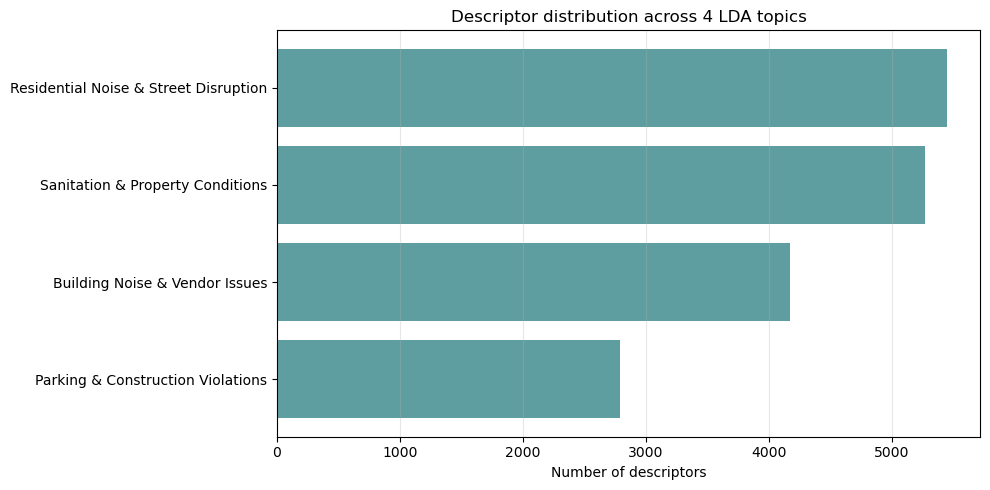


Sample descriptors per topic:

Sanitation & Property Conditions:
  - Bell/Buzzer/Intercom
  - Investigative Inspection
  - Signs Of Rodents

Residential Noise & Street Disruption:
  - Dirty Water (We)
  - Blocked Crosswalk
  - Loud Music/Party

Parking & Construction Violations:
  - Posted Parking Sign Violation
  - Lead Kit Request (Residential) (L10)
  - Commercial Overnight Parking

Building Noise & Vendor Issues:
  - Entire Building
  - Food Vendor
  - Banging/Pounding


In [23]:
# Apply K=4 LDA results: assign each descriptor its dominant topic
topic_distributions = lda.transform(count_matrix)
dominant_topic = topic_distributions.argmax(axis=1)

# Topic names based on top words inspection
topic_names = {
    0: 'Sanitation & Property Conditions',
    1: 'Residential Noise & Street Disruption',
    2: 'Parking & Construction Violations',
    3: 'Building Noise & Vendor Issues'
}

desc_data['topic_id'] = dominant_topic
desc_data['topic_name'] = desc_data['topic_id'].map(topic_names)

# How many descriptors fall into each topic?
topic_counts = desc_data['topic_name'].value_counts()
print("Distribution of descriptors across topics:")
print(topic_counts)

# Plot
plt.figure(figsize=(10, 5))
plt.barh(topic_counts.index[::-1], topic_counts.values[::-1], color='cadetblue')
plt.xlabel('Number of descriptors')
plt.title('Descriptor distribution across 4 LDA topics')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Show 3 example descriptors per topic
print("\nSample descriptors per topic:")
for tid in range(4):
    name = topic_names[tid]
    samples = desc_data[desc_data['topic_id'] == tid]['descriptor'].drop_duplicates().head(3).tolist()
    print(f"\n{name}:")
    for s in samples:
        print(f"  - {s}")

In [24]:
# Notebook metadata: Python and library versions
import sys
import platform
import importlib.metadata as md

libs = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "scipy",
    "nltk",
    "wordcloud"
]

versions = []
for lib in libs:
    try:
        versions.append(f"{lib} {md.version(lib)}")
    except md.PackageNotFoundError:
        pass

print(
    f"This notebook was generated using Python {sys.version.split()[0]} "
    f"on {platform.system()} {platform.release()} with the following libraries: "
    + ", ".join(versions)
)

This notebook was generated using Python 3.11.13 on Darwin 22.5.0 with the following libraries: numpy 2.4.4, pandas 3.0.2, matplotlib 3.10.8, seaborn 0.13.2, scikit-learn 1.8.0, scipy 1.17.1, nltk 3.9.4, wordcloud 1.9.6
